# NB07: (An Introduction to) Code Generation

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho



# 7.1 Code Generation

- Computer languages serve many purposes:
  - Programming
  - Data exchange
  - Modelling and specification
  - Visualization
  - ...

- For many of these purposes, the generation of executable code is a fundamental step
  - programming languages are the typical example

- A *compiler* is a system that translates programs written in a source language into a target language
  - in many cases, the target language is executable code for a machine
  - more generally, the target may also be another high-level or intermediate language

- The language processing pipeline studied so far corresponds to the *front-end* of a compiler:
  - lexical analysis
  - syntactic analysis
  - semantic analysis

- The *back-end* of a compiler includes **code generation**, the phase that completes this process
  - it takes the result of the previous phases and produces executable code

- The input to code generation is typically:
  - a semantically annotated and validated abstract syntax tree (AST)
  - auxiliary information such as the symbol table

- In many compilers, code generation is preceded by the construction of one or more *intermediate representations* (IRs)
  - these representations are designed to ease analysis and optimization

- Direct translation during parsing is also possible
  - however, this approach limits opportunities for optimization and modular design

- In this notebook, we focus on a simplified setting:
  - the generation of executable code for a stack-based virtual machine

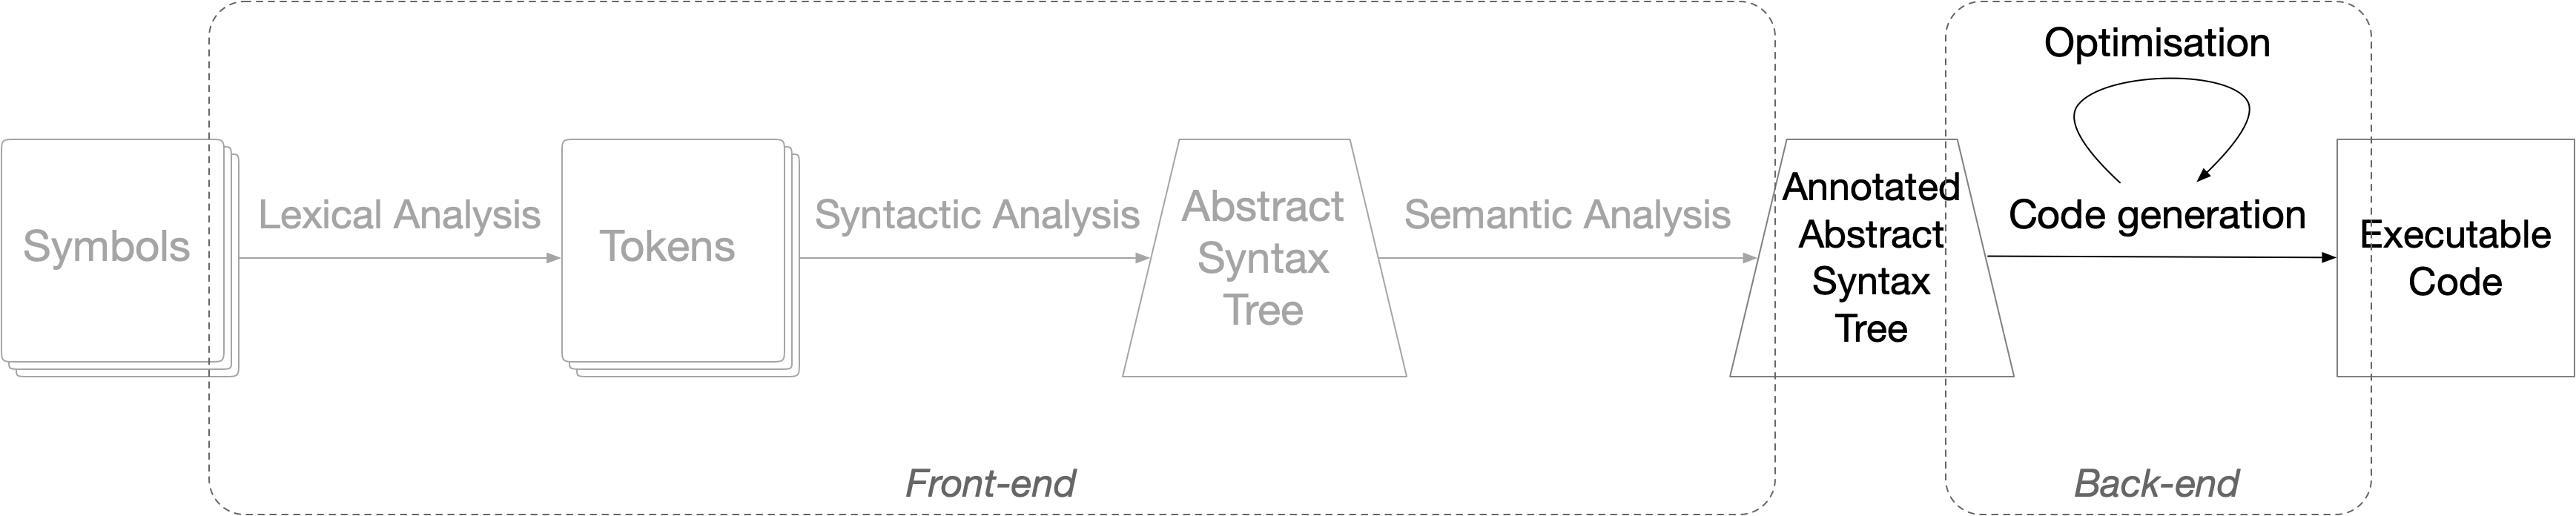

# 7.2 Stack-based Virtual Machines

## Target machines and execution models

- Code generation requires a *target machine*, the system that will execute the generated code

- A target machine is defined by:
  - its **execution model**
  - its **instruction set**

- There are different kinds of execution models

- A fundamental distinction is between:
  - *stack-based machines*
  - *register-based machines*

### Stack-based machines

- Computation is performed using an *operand stack*
  - instructions implicitly operate on the top elements of the stack
  - operands are not explicitly named

- Typical instruction pattern:
  - push values onto the stack
  - apply operations that consume operands and produce results on the stack

- Example:
  - Executing
    ```
    PUSH 2
    PUSH 3
    ADD
    ```
  - Leaves the value `5` on the top of the stack

### Register-based machines
  
- Computation is performed using a *fixed set of registers*
  - instructions explicitly refer to operands

- Example:
  - Executing
    ```
    MOV R1, 2
    MOV R2, 3
    ADD R3, R1, R2
    ```
  - Leaves the value `5` in register `R3`


## Process virtual machines

- Most real processors follow a register-based model

- Despite this, many compilers rely on *virtual machines* (VMs) to abstract the underlying hardware

- A **process virtual machine**:
  - provides an execution environment independent of the actual processor
  - improves portability
  - may introduce a performance overhead

- Examples include:
  - the JVM
  - the .NET CLR

- These virtual machines are often stack-based
  - they provide a simple and uniform execution model
  - they are well-suited as compilation targets

## A stack-based virtual machine

- We consider a simple stack-based VM developed in-house: the [EWVM](https://ewvm.epl.di.uminho.pt/)

- In stack-based VMs:
  - programs are sequences of instructions
  - instructions are executed sequentially
  - execution terminates when the last instruction is executed
  
- The state of the EWVM includes
    - an **operand stack**
    - a **call stack**
    - auxiliary **heaps**

- The operand stack is the central component of the execution model

- It is used to
  - evaluate expressions (intermediate values)
  - store global variables in a fixed region
  - when the program terminates, the result of a computation is typically left on the top


- The call stack is used to manage function calls

- The heaps are used for dynamic allocation

- The full instruction set of the language is available [here](https://ewvm.epl.di.uminho.pt/manual)

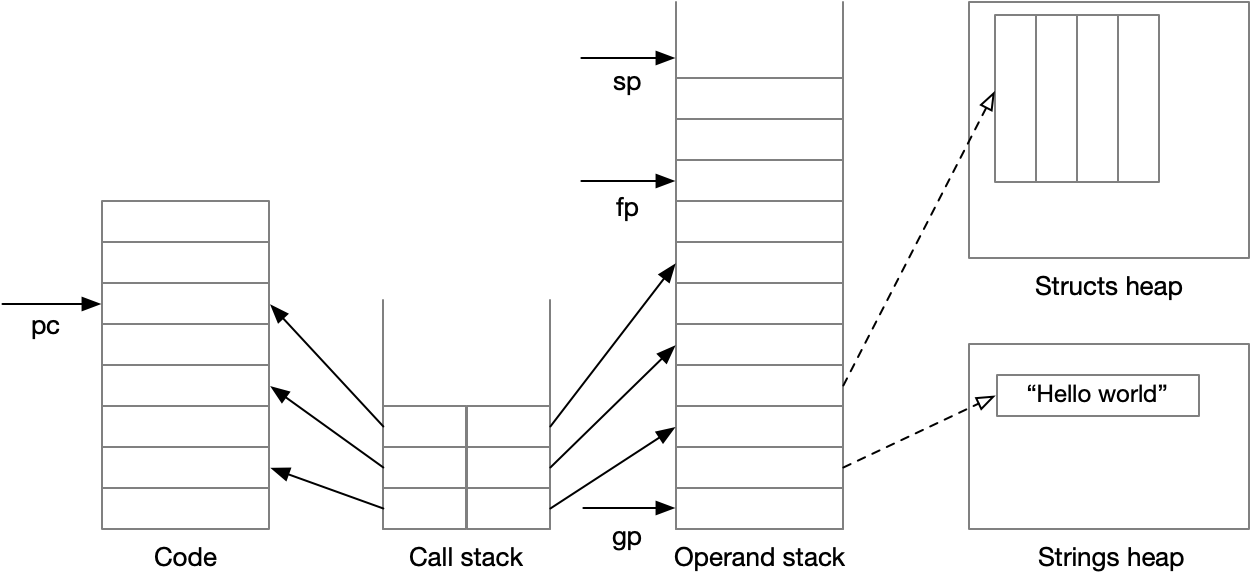

## Program counter

- A program is a sequence of instructions

- A *program counter* (PC) keeps track of the instruction being executed

- Without control flow instructions, execution is sequencial, and the PC is incremented at each step

- *Jumps* and *calls* change the value of the PC, changing the flow of execution

## Operand stack pointers

- The execution state of the machine is managed through a small set of **pointers**

- These pointers identify relevant regions of memory and stacks

- *Stack pointer* (SP)
  - points to the top of the operand stack
  - used for pushing and popping values

- *Global pointer* (GP)
  - identifies the region of the operand stack reserved for global variables
  - variables are accessed by fixed offsets relative to this region

- *Frame pointer* (FP)
  - identifies the memory region associated with the current execution context
  - it is used to implement functions and local variables

## Implementing operations

- In the following, we distinguish:
  - **expressions**, which leave a value on the stack
  - **statements**, which may produce side effects (e.g., assignments, IO)

- Code generation for expressions for a stack-based VM can be achieved by a *post-order traversal of the AST*

- For a binary operation:
  - generate code for the left operand
  - generate code for the right operand
  - apply the operation

- Operationally:
  - evaluating an operand pushes its value onto the stack
  - applying an operation pops its operands from the stack and pushes the result

- Code generation is *compositional*:
  - the code for a construct is built from the code of its components
  
- Basic integer instructions:
  - `PUSHI n`: push integer $n$ onto the stack
  - `ADD`, `SUB`, `MUL`, `DIV`: pop two values from the stack, apply the operation, push the result onto the stack

## ✏️ Basic expression example: Arithmetic operations

- Let us consider a simple expression language in fully parenthesized prefix notation (S-expressions), specified by the following grammar

  - Σ = {`ADD`, `SUB`, `MUL`, `DIV`, `INT`, `(`, `)`}

    ```
    Expr : (BinIntOp Expr Expr)
         | INT
    BinIntOp : ADD | SUB | MUL | DIV
    ```

- Let us consider the expression `(+ 33 (* 52 28))`, which has the following AST


  ```
     ADD
    /   \
  33     MUL
        /   \
      52     28
  ```

- Post-order traversal (left → right → node):

  ```
  33   52   28   MUL   ADD
  ```

- Corresponding VM instructions:

  ```
  PUSHI 33
  PUSHI 52
  PUSHI 28
  MUL
  ADD
  ```

- Simulating execution:
  - Initial stack:
    ```
      ┌──────┐
      └──────┘ <-- GP=SP
    ```
  - `PUSHI 33` (left operand of `ADD`)
    ```
      ┌──────┐ <-- SP
      │  33  │ 0 (literal 33)
      └──────┘ <-- GP
    ```
  - `PUSHI 52` (right operand of `ADD`, which starts with left operand of `MUL`)
    ```
      ┌──────┐ <-- SP
      │  52  │ 1 (literal 52)
      ├──────┤
      │  33  │ 0 (literal 33)
      └──────┘ <-- GP
    ```
  - `PUSHI 28` (right operand of `MUL`)

    ```
      ┌──────┐ <-- SP
      │  28  │ 2 (literal 28)
      ├──────┤
      │  52  │ 1 (literal 52)
      ├──────┤
      │  33  │ 0 (literal 33)
      └──────┘ <-- GP
    ```
  - `MUL` (finished `MUL`, right operand of `ADD` in stack)

    ```
      ┌──────┐ <-- SP
      │ 1456 │ 1 (result of 52 * 28)
      ├──────┤
      │  33  │ 0 (literal 33)
      └──────┘ <-- GP
    ```
  - `ADD` (finished `+`, root of tree in stack)

    ```
      ┌──────┐ <-- SP
      │ 1489 │ 0 (result of 33 + 52 * 28)
      └──────┘ <-- GP
    ```

## Variable allocation

- Variables require storage in memory

- In this simplified setting:
  - variables are assigned fixed positions in a global region of the operand stack
  - the code generator maps variables to these positions
  - GP marks the start of this region
  - in practice, this region is the lower part of the operand stack and remains fixed during execution

- Relevant instructions:
  - `PUSHG n`: pushes the value stored at position $n$ of the global region onto the stack
  - `STOREG n`: pops a value from the stack and stores it at position $n$ of the global region

## ✏️ Basic program example: Simple language with assignments

- Let us now extend our expression language with variable declaration and assignment statements

  - Σ = {`DECL`, `SET`, `ADD`, `SUB`, `MUL`, `DIV`, `INT`, `ID`, `(`, `)`}

    ```
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
    Declaration : (DECL ID)
    Assignment : (SET ID Expr)
    Expr : (BinIntOp Expr Expr)
         | INT
         | ID
    BinIntOp : ADD | SUB | MUL | DIV
    ```

- A sequence of statements is translated by concatenating the code generated for each statement

- Let us try to translate the following program
  ```
  (decl x)
  (decl y)
  (set x 53)
  (set y (* 20 x))
  ```

- The translator detects the declaration of variables `x` and `y`; let's assume they were assigned positions `0` and `1` in the global region, respectively

- It will start by reserving those positions in the stack, for instance, initializing them with 0
  ```
  PUSHI 0
  PUSHI 0
  ```

- Then it will assign to `x` value 53, by using its address in the global region (`0`)
  ```
  PUSHI 53
  STOREG 0
  ```

- Then, it will compute the value of expression `x * 20`, and leave it in the stack

- AST:

  ```
      *
    /   \
  20     x
  ```

- Post-order traversal:

  ```
  20   x   *
  ```

- Corresponding instructions:

  ```
  PUSHI 20
  PUSHG 0
  MUL
  ```

- Finally, it takes the value on top of the stack and stores it in `y`  

  ```
  STOREG 1
  ```



- Example execution (you can try it in the EWVM):
  ```
  PUSHI 0    // allocate space for x
  PUSHI 0    // allocate space for y
  PUSHI 53   // push integer literal 53
  STOREG 0   // store value in x
  PUSHI 20   // push integer literal 20
  PUSHG 0    // push value of x
  MUL        // pop operands and push result of multiplication
  STOREG 1   // store value in y
  ```
  - Initial stack:
    ```
    ┌──────┐
    └──────┘ <-- GP=SP
    ```

  - Two `PUSHI 0`
    ```
    ┌──────┐ <-- SP
    │   0  │ (y)
    ├──────┤
    │   0  │ (x)
    └──────┘ <-- GP
    ```

  - `PUSHI 53`
    ```
    ┌──────┐ <-- SP
    │  53  │  
    ├──────┤
    │   0  │ (y)
    ├──────┤
    │   0  │ (x)
    └──────┘ <-- GP
    ```

  - `STOREG 0`
    ```
    ┌──────┐ <-- SP
    │   0  │ (y)
    ├──────┤
    │  53  │ (x)
    └──────┘ <-- GP
    ```

  - `PUSHI 20`
    ```
    ┌──────┐ <-- SP
    │  20  │
    ├──────┤
    │   0  │ (y)
    ├──────┤
    │  53  │ (x)
    └──────┘ <-- GP
    ```
  - `PUSHG 0`
    ```
    ┌──────┐ <-- SP
    │  53  │
    ├──────┤
    │  20  │
    ├──────┤
    │   0  │ (y)
    ├──────┤
    │  53  │ (x)
    └──────┘ <-- GP
    ```
  - `MUL`

    ```
    ┌──────┐ <-- SP
    │ 1060 │
    ├──────┤
    │   0  │ (y)
    ├──────┤
    │  53  │ (x)
    └──────┘ <-- GP
    ```
  - `STOREG 1`

    ```
    ┌──────┐ <-- SP
    │ 1060 │ (y)
    ├──────┤
    │  53  │ (x)
    └──────┘ <-- GP
    ```

## Control Flow

- By default, instructions are executed sequentially
  - in the order in which they appear in the program

- Control flow instructions allow altering this order

- However, control flow in machine code is not as structured as in programming languages
  - the basic control structures are *jumps* to labelled instructions

## Labels

  - A label identifies a position in the program
  
  - Labels are used as targets for jump instructions
    - a label `L` is declared as `L:`

  - Unconditional jumps continue execution at given label
    - instruction `JUMP L` continues execution in label `L`

  - Example (infinite loop):
    ```
    L1:
    PUSHI 1
    JUMP L1
    ```



## Boolean values

- In machine code, Boolean values are represented as integers:
  - 0 represents false
  - any non-zero value represents true

- Comparison operations pop two operands and push a Boolean value into the stack

- Typical instructions:
  - `EQUAL`, `INF`, `SUP`, `INFEQ`, `SUPEQ`: comparisons between integers (produce 0 or 1)
  - `AND`, `OR`: logical combinators (treat non-zero values as true and produce 0 or 1)


## Conditional jumps

- Conditional jumps are used to implement control flow structures
  - conditionals, loops, ...
  
- The instruction `JZ L` (jump to `L` if zero)
  - pops the top value of the stack
  - if the value is 0, execution continues at label `L`
  - otherwise, execution proceeds to the next instruction

## Patterns for control flow

### If statement

- Source:
  ```
  if (cond) S
  ```

- Code:
  ```
  <code for cond>
  JZ IF_END
  <code for S>
  IF_END:
  ```

### If-else statement

- Source:
  ```
  if (cond) S1 else S2
  ```

- Code:
  ```
  <code for cond>
  JZ IF_ELSE
  <code for S1>
  JUMP IF_END
  IF_ELSE:
  <code for S2>
  IF_END:
  ```

### While loop

- Source:
  ```
  while (cond) S
  ```

- Code:
  ```
  WHILE_START:
  <code for cond>
  JZ WHILE_END
  <code for S>
  JUMP WHILE_START
  WHILE_END:
  ```

## Label management

- Labels for control flow structures are generated automatically by the compiler
  - it must keep track of defined labels and to which control structures they belong to
  - it must gurantee that they are unique in each context of the program

## ✏️ Basic program example: Conditional statements

- Let us again extend our simple language with conditional expressions (*not* conditional statements)

  - Σ = {`DECL`, `SET`, `IF`, `ADD`, `SUB`, `MUL`, `DIV`, `LT`, `GT`, `EQ`, `INT`, `ID`, `(`, `)`}

    ```
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
    Declaration : (DECL ID)
    Assignment : (SET ID Expr)
    Expr : (BinIntOp Expr Expr)
         | (IF Condition Expr Expr)
         | INT
         | ID
    Condition : (BinCmpOp Expr Expr)
    BinIntOp : ADD | SUB | MUL | DIV
    BinCmpOp : LT | GT | EQ
    ```

- In conditional expressions:
  - both branches must leave exactly one value on the stack
  - this ensures that the overall expression produces a single result

- Let us try to translate the following program (an assignment of a conditional expression)

  ```
  (decl x)
  (set x 20)
  (set y (if (> x 0) x 0))
  ```

- Assigning `20` to `x` (assuming it has position `0`) is done has follows
  ```
  PUSHI 20
  STOREG 0
  ```

- The conditional expression is encoded as follows, using labels and jumps
  ```
         IF
     /   |   \
    >    x    0
   /  \  
  x    0
  ```

  ```
  // condition
  PUSHG 0
  PUSHI 0
  SUP
  JZ IFELSE
  // if branch
  PUSHG 0
  JUMP IFEND
  IFELSE:
  // else branch
  PUSHI 0
  IFEND:
  ```

- Finally, the result is assigned to `y` (assuming it has position `1`)
  ```
  STOREG 1
  ```

## Performing IO

- IO involves manipulating strings, which require dynamic memory

- The EWVM has a string heap specifically for this purpose

- The operand stack stores *addresses* to the string heap, rather than the literal strings

- Relevant instructions:
  - `WRITES`: pop an address from the stack and send the corresponding string in the heap to the output
  - `READ`: read a string from the input, store it in the heap, push the corresponding address into the stack
  - `ATOI`: pop a string address from the stack, convert it to integer, and push it into the stack
  - `STRI`: pop an integer from the stack, convert it to string, send it to the heap and push the corresponding address into the stack
  - `WRITEI`: pop an integer from the stack, convert it to string, and send it directly to the output

## ✏️ Basic program example: Conditional statements

- Let us again extend our simple language with IO statements and conditional expressions (*not* conditional statements)

  - Σ = {`DECL`, `SET`, `PRINT`, `READ`, `IF`, `ADD`, `SUB`, `MUL`, `DIV`, `LT`, `GT`, `EQ`, `INT`, `ID`, `(`, `)`}

    ```
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
              | Print
              | Read
    Declaration : (DECL ID)
    Assignment : (SET ID Expr)
    Read : (READ ID)
    Print : (PRINT Expr)
    Expr : (BinIntOp Expr Expr)
         | (IF Condition Expr Expr)
         | INT
         | ID
    Condition : (BinCmpOp Expr Expr)
    BinIntOp : ADD | SUB | MUL | DIV
    BinCmpOp : LT | GT | EQ
    ```

- Let us try to translate the following program (read a value, print it if positive, otherwise print 0)

  ```
  (decl x)
  (read x)
  (set y (if (> x 0) x 0))
  (print y)
  ```

- The input reading instruction can be translated as follows (assuming `x` has global position `0`)
  ```
  PUSHS "Write a value for x: "
  WRITES
  READ
  ATOI
  STOREG 0
  ```

- The conditional expression is encoded as already seen
  ```
  PUSHG 0
  PUSHI 0
  SUP
  JZ IFELSE
  PUSHG 0
  JUMP IFEND
  IFELSE:
  PUSHI 0
  IFEND:
  ```

- Finally, producing output is performed by:
  ```
  WRITEI
  ```

- The complete program, you can animate it in EWVM:

  ```
  PUSHI 0                         // allocate space for x
  PUSHS "Write a value for x: "   // allocate string in the heap, address pushed into stack
  WRITES                          // output string from heap
  READ                            // read string from input to heap, address pushed into stack
  ATOI                            // convert string whose address in stack into integer, push into stack
  STOREG 0                        // store value in x
  PUSHG 0                         // push value of x
  PUSHI 0                         // push literal integer 0
  SUP                             // pop operands, push result of >
  JZ IFELSE                       // pop value from the stack, if 0 jump to end of conditional
  PUSHG 0                         // push value of x
  JUMP IFEND                      // jump to end of conditional
  IFELSE:                         // marks else branch of conditional
  PUSHI 0                         // push literal integer 0
  IFEND:                          // marks end of conditional, both branches end here
  WRITEI                          // send integer value to output
  ```

# 7.3 Code Generation in Practice

Let us try to encode a complete language processing pipeline for the example language using `Ply`:
  - lexical analysis
  - syntactic analysis
  - semantic analysis
  - machine code generation

In [ ]:
!pip install ply
__file__ = "Untitled.ipynb" # needed to run Ply inside notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.4 MB/s eta 0:00:00


⚠️ *Note:* since `Ply` relies on reflection, it is not prone to having multiple specifications in the same module
  - This leads to some conflicts when writing specifications in notebooks, which is not recommended
  - Either run the code outside the notebook, restart the notebook session if it becomes corrupted, or run the following functions

In [ ]:
def cleanLexerGlobals():
  "Remove ply.lex identifiers from the global context."
  for t in [n for n in globals() if n.startswith("t_") or n in ("tokens", "literals", "states")]:
    del globals()[t]

def cleanParserGlobals():
  "Remove ply.yacc identifiers from the global context."
  for t in [n for n in globals() if n.startswith("p_")]:
    del globals()[t]
  import os
  try: # avoid conflicts in temp files when running from notebook
    os.remove("parsetab.py")
  except FileNotFoundError:
    pass

## Lexical analysis

- There are no complex token rules for this language

- Since there are many keywords, rather than defining a rule for each, keyword lexemes are caught by the regular expression for `ID`, and their type updated accordingly

In [ ]:
import ply.lex as lex

class LexError(Exception):
    pass

In [ ]:
cleanLexerGlobals()

tokens = ("DECL", "SET", "PRINT", "READ",
          "INT", "ID", "TRUE", "FALSE",
          "IF", "ADD", "SUB", "MUL", "DIV", "LT", "GT", "EQ")

literals = "()"

t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"
t_LT = r"<"
t_GT = r">"
t_EQ = r"="

keywords = {
    "true"  : "TRUE",
    "false" : "FALSE",
    "decl"  : "DECL",
    "set"   : "SET",
    "print" : "PRINT",
    "read"  : "READ",
    "if"    : "IF" }

def t_ID(t):
  r"[A-Za-z]\w*"
  if t.value in keywords:
    t.type = keywords[t.value]
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

## Syntactic analysis

- The grammar for the language can be almost directly translated into `Ply.yacc`, except for some syntactic adjustments (e.g., quoting literal tokens, one production per line)

In [ ]:
import ply.yacc as yacc

class SyntaxError(Exception):
    pass

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    """

def p_statements(p):
    r"""
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
              | Print
              | Read
    """

def p_decl(p):
    r"""
    Declaration : "(" DECL ID ")"
    """

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """

def p_read(p):
    r"""
    Read : "(" READ ID ")"
    """

def p_expr_bin(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
    """

def p_expr_if(p):
    r"""
    Expr : "(" IF Condition Expr Expr ")"
    """

def p_expr_int(p):
    r"""
    Expr : INT
    """

def p_expr_id(p):
    r"""
    Expr : ID
    """

def p_cond(p):
    r"""
    Condition : "(" BinCmpOp Expr Expr ")"
              | TRUE
              | FALSE
    """

def p_ops(p):
  r"""
  BinIntOp : ADD
           | SUB
           | MUL
           | DIV
  BinCmpOp : LT
           | GT
           | EQ
  """

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    parser.parse(text)
    print("Program is syntactically correct")
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
ex1 = """
(decl x)
(read x)
(decl y)
(set y (if (< x 0) 0 x))
(print y)
"""

In [ ]:
parse(ex1)

Program is syntactically correct


## Semantic analysis

- A symbol table is essential both for semantic analysis and code translation

- For this language, we must keep track of the declared variables, and whether they have been initialized

- We will also use the symbol table to assign an index to each declared variable

- Static semantic errors are raised if variables are used undeclared or uninitialized

- We reuse the previous parser, introducing semantic actions to perform semantic checks

In [ ]:
class SemanticError(Exception):
    pass

In [ ]:
# A simple symbol table, registers whether the variable has been initialized
class SymbolTable():
  def __init__(self):
    self.__table = {}
    self.__label_count = 0

  def __repr__(self):
    return self.__table.__repr__()

  # return all declared symbols
  def symbols(self):
    return self.__table.keys()

  # return variable info, but only if declared
  def lookup(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    else:
      return self.__table.get(id)

  # declare an identifier, set it as uninitialized and assign an index, do not allow duplicate declarations
  def declare(self, id):
    idx = len(self.__table)
    if id in self.__table:
      raise SemanticError(f"Duplicate declaration: {id}")
    self.__table[id] = { 'index': idx, 'initialized': False }

  # mark a variable as initialized, but only if declared
  def initialize(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    self.__table[id]['initialized'] = True

  # guarantees unique identifier for labels
  def new_label(self):
    self.__label_count += 1
    return self.__label_count


In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    """

def p_statements(p):
    r"""
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
              | Print
              | Read
    """

def p_decl(p):
    r"""
    Declaration : "(" DECL ID ")"
    """
    p.parser.symbols.declare(p[3])

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    p.parser.symbols.lookup(p[3])
    p.parser.symbols.initialize(p[3])

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """

def p_read(p):
    r"""
    Read : "(" READ ID ")"
    """
    p.parser.symbols.lookup(p[3])
    p.parser.symbols.initialize(p[3])

def p_expr_bin(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
    """

def p_expr_if(p):
    r"""
    Expr : "(" IF Condition Expr Expr ")"
    """

def p_expr_int(p):
    r"""
    Expr : INT
    """

def p_expr_id(p):
    r"""
    Expr : ID
    """
    if not p.parser.symbols.lookup(p[1])['initialized']:
      raise SemanticError(f"Uninitialized variable: {p[1]}")


def p_cond(p):
    r"""
    Condition : "(" BinCmpOp Expr Expr ")"
              | TRUE
              | FALSE
    """

def p_ops(p):
  r"""
  BinIntOp : ADD
           | SUB
           | MUL
           | DIV
  BinCmpOp : LT
           | GT
           | EQ
  """

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    parser.symbols = SymbolTable()
    parser.parse(text)
    print("Program is semantically correct")
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
parse(ex1)

Program is semantically correct


In [ ]:
ex2 = """
(decl x)
(read x)
(set y (if (< x 0) 0 x))
(print y)
"""

In [ ]:
parse(ex2)

Parsing failed: Undeclared variable: y


## Code generation: Syntax-directed translation

- One possible approach to code generation is to translate programs directly into VM instructions during parsing

- This is simple to implement:
  - the translation is defined as semantic actions for the grammar's productions
  - no need to create the AST explicitly or implement tree traversals
  - may be more efficient since everything happens in a single pass

- In practice, each production generates a list of VM instructions to execute, which are concatenated in each grammar production

- However, it also has drawbacks:
  - it makes it hard to implement optimizations, since there is no global view of the program
  - it makes code generation tightly couples with the grammar, making it hard to update the language and the target VM

- Here, we extend the previous parser, introducing semantic actions to perform semantic checks

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    """
    # allocate one slot per declared variable
    alloc = ["PUSHI 0" for i in p.parser.symbols.symbols()]
    p[0] = alloc + p[1]

def p_statements(p):
    r"""
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
              | Print
              | Read
    """
    # simply concatenate instructions from each statement
    if len(p) == 2:
      p[0] = p[1]
    else:
      p[0] = p[1] + p[2]

def p_decl(p):
    r"""
    Declaration : "(" DECL ID ")"
    """
    p.parser.symbols.declare(p[3])
    # no code to generate, only affects symbol table, used elsewhere
    p[0] = []

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    var_info = p.parser.symbols.lookup(p[3])
    p.parser.symbols.initialize(p[3])
    # produce the value of the expression, and store it in the global region
    p[0] = p[4] + [f"STOREG {var_info['index']}"]

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """
    # produce the value of the expression, and send it to the output
    p[0] = p[3] + [f"WRITEI"]

def p_read(p):
    r"""
    Read : "(" READ ID ")"
    """
    var_info = p.parser.symbols.lookup(p[3])
    p.parser.symbols.initialize(p[3])
    # read a string from the input, convert it to integer, and store it in the global region
    p[0] = [f'PUSHS "Value for {p[3]}: "', "WRITES", "READ", "ATOI", f"STOREG {var_info['index']}"]

def p_expr_bin(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
    """
    # push instructions for both operands, then apply the operation (post-order)
    p[0] = p[3] + p[4] + p[2]

def p_expr_if(p):
    r"""
    Expr : "(" IF Condition Expr Expr ")"
    """
    # create unique label identifiers
    label_id = p.parser.symbols.new_label()
    else_label = f"ELSE{label_id}"
    end_label = f"FI{label_id}"
    # push instructions for condition, jump depending on the result
    cond = p[3] + [f"JZ {else_label}"]
    # set the labels for the else branch and the end of the conditional
    branches = p[4] + [f"JUMP {end_label}", f"{else_label}:"] + p[5] + [f"{end_label}:"]
    p[0] = cond + branches

def p_expr_int(p):
    r"""
    Expr : INT
    """
    # push literal integer
    p[0] = [f"PUSHI {p[1]}"]

def p_expr_id(p):
    r"""
    Expr : ID
    """
    var_info = p.parser.symbols.lookup(p[1])
    if not var_info['initialized']:
      raise SemanticError(f"Uninitialized variable: {p[1]}")
    # push the value from the global region
    p[0] = [f"PUSHG {var_info['index']}"]

def p_cond_bin(p):
    r"""
    Condition : "(" BinCmpOp Expr Expr ")"
    """
    # push instructions for both operands, then apply the operation (post-order)
    p[0] = p[3] + p[4] + p[2]

def p_cond_bin_true(p):
    r"""
    Condition : TRUE
    """
    p[0] = ["PUSHI 1"]

def p_cond_bin_false(p):
    r"""
    Condition : FALSE
    """
    p[0] = ["PUSHI 0"]

def p_ops_add(p):
    r"""
    BinIntOp : ADD
    """
    p[0] = ["ADD"]

def p_ops_sub(p):
    r"""
    BinIntOp : SUB
    """
    p[0] = ["SUB"]

def p_ops_mul(p):
    r"""
    BinIntOp : MUL
    """
    p[0] = ["MUL"]

def p_ops_div(p):
    r"""
    BinIntOp : DIV
    """
    p[0] = ["DIV"]

def p_ops_lt(p):
    r"""
    BinCmpOp : LT
    """
    p[0] = ["INF"]

def p_ops_gt(p):
    r"""
    BinCmpOp : GT
    """
    p[0] = ["SUP"]

def p_ops_eq(p):
    r"""
    BinCmpOp : EQ
    """
    p[0] = ["EQUAL"]

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    parser.symbols = SymbolTable()
    code = parser.parse(text)
    print("Program is semantically correct.")
    print("Execute in EWVM:")
    print()
    print("\n".join(code))
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
ex0 = """
(print (+ 30 25))
"""

In [ ]:
parse(ex0)

Program is semantically correct.
Execute in EWVM:

PUSHI 30
PUSHI 25
ADD
WRITEI


In [ ]:
parse(ex1)

Program is semantically correct.
Execute in EWVM:

PUSHI 0
PUSHI 0
PUSHS "Value for x: "
WRITES
READ
ATOI
STOREG 0
PUSHG 0
PUSHI 0
INF
JZ ELSE1
PUSHI 0
JUMP FI1
ELSE1:
PUSHG 0
FI1:
STOREG 1
PUSHG 1
WRITEI


## Code generation: AST-based translation

- An alternative approach to code generation is to first construct an abstract syntax tree (AST) during parsing

- Code generation is then performed in a separate phase, by traversing the AST
typically using a recursive or post-order traversal

- This approach is slightly more involved, it requires
  - defining data structures for the AST
  - implementing a traversal algorithm for code generation

- In practice, each node of the AST is translated into a sequence of instructions
  - the final program is obtained by composing the code generated for each node

- This separation of concerns has important advantages:
  - it decouples parsing from code generation
  - it provides a global view of the program structure
  - it makes it easier to implement analysis and optimizations

- However, it may introduce some overhead:
  - the AST must be explicitly constructed and stored in memory

- Let us adapt the previous parser to generate a simple AST based on nested *tuples*
  - In practice, we should define classes for each kind of node with proper support for tree traversals

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    """
    p[0] = ("program", p[1])

def p_statements(p):
    r"""
    Statements : Statements Statement
               | Statement
    """
    if len(p) == 2:
      p[0] = [p[1]]
    else:
      p[0] = p[1] + [p[2]]

def p_statement(p):
    r"""
    Statement : Declaration
              | Assignment
              | Print
              | Read
    """
    p[0] = p[1]

def p_decl(p):
    r"""
    Declaration : "(" DECL ID ")"
    """
    p[0] = ("decl", p[3])

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    p[0] = ("set", p[3], p[4])

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """
    p[0] = ("print", p[3])

def p_read(p):
    r"""
    Read : "(" READ ID ")"
    """
    p[0] = ("read", p[3])

def p_expr_bin(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
    """
    p[0] = (p[2], p[3], p[4])

def p_expr_if(p):
    r"""
    Expr : "(" IF Condition Expr Expr ")"
    """
    p[0] = ("if", p[3], p[4], p[5])

def p_expr_int(p):
    r"""
    Expr : INT
    """
    p[0] = ("int", p[1])

def p_expr_id(p):
    r"""
    Expr : ID
    """
    p[0] = ("var", p[1])

def p_cond_bin(p):
    r"""
    Condition : "(" BinCmpOp Expr Expr ")"
    """
    p[0] = (p[2], p[3], p[4])

def p_cond_bin_true(p):
    r"""
    Condition : TRUE
    """
    p[0] = ("true",)

def p_cond_bin_false(p):
    r"""
    Condition : FALSE
    """
    p[0] = ("false",)

def p_ops_add(p):
    r"""
    BinIntOp : ADD
    """
    p[0] = "add"

def p_ops_sub(p):
    r"""
    BinIntOp : SUB
    """
    p[0] = "sub"

def p_ops_mul(p):
    r"""
    BinIntOp : MUL
    """
    p[0] = "mul"

def p_ops_div(p):
    r"""
    BinIntOp : DIV
    """
    p[0] = "div"

def p_ops_lt(p):
    r"""
    BinCmpOp : LT
    """
    p[0] = "lt"

def p_ops_gt(p):
    r"""
    BinCmpOp : GT
    """
    p[0] = "gt"

def p_ops_eq(p):
    r"""
    BinCmpOp : EQ
    """
    p[0] = "eq"

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    ast = parser.parse(text)
    print("Program is syntactically correct.")
    return ast
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


- The parser now simply generates the AST

In [ ]:
parse(ex1)

Program is syntactically correct.


('program',
 [('decl', 'x'),
  ('read', 'x'),
  ('decl', 'y'),
  ('set',
   'y',
   ('if', ('lt', ('var', 'x'), ('int', 0)), ('int', 0), ('var', 'x'))),
  ('print', ('var', 'y'))])

- Let us define an AST traversal to check semantic validity and build the symbol table

In [ ]:
from functools import reduce

def validate(e, symbols):
  match e:
    case ("program", s):
      list(map(lambda x: validate(x, symbols), s))

    case ("decl", i):
      symbols.declare(i)

    case ("set", i, e):
      symbols.lookup(i)
      symbols.initialize(i)
      validate(e, symbols)

    case ("print", e):
      validate(e, symbols)

    case ("read", i):
      symbols.lookup(i)
      symbols.initialize(i)

    case ("add", l, r):
      validate(l, symbols)
      validate(r, symbols)

    case ("sub", l, r):
      validate(l, symbols)
      validate(r, symbols)

    case ("div", l, r):
      validate(l, symbols)
      validate(r, symbols)

    case ("mul", l, r):
      validate(l, symbols)
      validate(r, symbols)

    case ("lt", l, r):
      validate(l, symbols)
      validate(r, symbols)

    case ("gt", l, r):
      validate(l, symbols)
      validate(r, symbols)

    case ("eq", l, r):
      validate(l, symbols)
      validate(r, symbols)

    case ("if", cond, e1, e2):
      validate(cond, symbols)
      validate(cond, e1)
      validate(cond, e2)

    case e:
      pass

In [ ]:
symbols = SymbolTable()
ast = parse(ex1)
validate(ast, symbols)

Program is syntactically correct.


- Now let us define code generation as another AST traversal, that already assumes semantic validity and the existance of the symbol table

In [ ]:
from functools import reduce

def generate(e, symbols):
  match e:
    case ("program", s):
      stmts = reduce(lambda x,y:x+y,map(lambda x: generate(x, symbols), s))
      return ["PUSHI 0" for i in symbols.symbols()] + stmts

    case ("decl", i):
      return []

    case ("set", i, e):
      var_info = symbols.lookup(i)
      return generate(e, symbols) + [f"STOREG {var_info['index']}"]

    case ("print", e):
      return generate(e, symbols) + [f"WRITEI"]

    case ("read", i):
      var_info = symbols.lookup(i)
      return [f'PUSHS "Value for {i}: "', "WRITES", "READ", "ATOI", f"STOREG {var_info['index']}"]

    case ("add", l, r):
      return generate(l, symbols) + generate(r, symbols) + ["ADD"]

    case ("sub", l, r):
      return generate(l, symbols) + generate(r, symbols) + ["SUB"]

    case ("div", l, r):
      return generate(l, symbols) + generate(r, symbols) + ["DIV"]

    case ("mul", l, r):
      return generate(l, symbols) + generate(r, symbols) + ["MUL"]

    case ("lt", l, r):
      return generate(l, symbols) + generate(r, symbols) + ["INF"]

    case ("gt", l, r):
      return generate(l, symbols) + generate(r, symbols) + ["SUP"]

    case ("eq", l, r):
      return generate(l, symbols) + generate(r, symbols) + ["EQ"]

    case ("if", cond, e1, e2):
      label_id = symbols.new_label()
      else_label = f"ELSE{label_id}"
      end_label = f"FI{label_id}"
      cond = generate(cond, symbols) + [f"JZ {else_label}"]
      branches = generate(e1, symbols) + [f"JUMP {end_label}", f"{else_label}:"] + generate(e2, symbols) + [f"{end_label}:"]
      return cond + branches

    case ("var", x):
      idx = symbols.lookup(x)["index"]
      return [f"PUSHG {idx}"]

    case ("int", n):
      return [f"PUSHI {n}"]

    case ("true",):
      return [f"PUSHI 1"]

    case ("false",):
      return [f"PUSHI 0"]

In [ ]:
symbols = SymbolTable()
ast = parse(ex1)
validate(ast, symbols)
print(symbols)
code = generate(ast, symbols)
print("\n".join(code))

Program is syntactically correct.
{'x': {'index': 0, 'initialized': True}, 'y': {'index': 1, 'initialized': True}}
PUSHI 0
PUSHI 0
PUSHS "Value for x: "
WRITES
READ
ATOI
STOREG 0
PUSHG 0
PUSHI 0
INF
JZ ELSE1
PUSHI 0
JUMP FI1
ELSE1:
PUSHG 0
FI1:
STOREG 1
PUSHG 1
WRITEI


# 7.4 Frames and Function Calls

- So far, we have considered programs *without* functions
  - all variables were stored in a global region
  - execution took place within a single control context

- However, most programming languages support **functions** (or procedures)
  - functions introduce *nested execution contexts*
  - each function call has its own local state

- To support this, machines use the notion of a *frame* (or activation record)

- A frame represents the state of a function call, and contains:
  - local variables
  - parameters
  - bookkeeping information (e.g., return address)

- Each time a function is called:
  - a new frame is created
  - a function accesses its frame using the *frame pointer* (FP)

- When the function returns:
  - its frame is discarded

- This mechanism allows:
  - recursion
  - local variables

## Managing frames

- A function is defined by a *label* in the program

- To call a function, its *address* is pushed to the operand stack using `PUSHA`

- In the EWVM, a new frame is established by the instruction `CALL`:
  - takes an *instruction address* from the operand stack
  - pushes the current *program pointer* and *frame pointer* to the call stack
  - updates the program pointer to the called function
  - updates the frame pointer to the current stack pointer

- When a function terminates, the instruction `RETURN` is called, which:
  - updates the stack pointer to the current frame pointer
  - pops the frame pointer and the program counter from the call stack



## Managing arguments and return values

- A function call may consume arguments and produce results

- The code calling the function should reserve space for the arguments and the return value

- Since the frame pointer is set *after* the arguments and return slot are pushed, the function then accesses these values by looking *behind* its frame pointer
  - This is done with negative offsets

- This way, when the function terminates, the calling code knows where to expect the result

- A possible flow for an *n*-ary function:
  - Reserve space for the return values with `PUSHI 0`
  - Push the *n* arguments into the stack
  - Push the function address into the stack with `PUSHA`
  - `CALL` the function
  - The function accesses parameter $i$ with `PUSHL -i`
  - The function stores the result with `STOREL -(n+1)`
  - The function `RETURN`s
  - The calling code cleans the arguments with `POP n`
  - The return value remains in the top of the stack

## ✏️ Basic function example: Doubling a number

- Let us consider a very simply function to calculate the square of a number

- Assuming position -1 of the frame has the argument, and -2 is reserved for the return value, this could be achieved as follows:

    ```
    SQUARE:     // function name
      PUSHL -1  // load argument
      PUSHL -1  // load argument
      MUL       // multiply
      STOREL -2 // store return value
      RETURN    // return
    ```

- The calling code must reserve space for the return value and push the argument

  ```
  [1]  PUSHS "Number: "
  [2]  WRITES
  [3]  READ
  [4]  ATOI
  [5]  PUSHI 0
  [6]  PUSHG 0
  [7]  PUSHA SQUARE
  [8]  CALL
  [9]  POP 1
  [10] PUSHS "Square: "
  [11] WRITES
  [12] WRITEI
  [13] STOP
  ```

- Example execution
  - Before the function is called
    ```
    ┌─────┐ <-- SP
    │  3  │ 1 (argument, read from input)
    ├─────┤             
    │  0  │ 0 (return slot, 0 initialized)    ┌─────┬─────┐
    └─────┘ <-- GP, FP                        └─────┴─────┘
                                                PCs   FPs
    ```
  - After function called, FP updated
    ```
    ┌─────┐ <-- FP, SP
    │  3  │ 1 (argument, read from input)
    ├─────┤                                   ┌─────┬─────┐
    │  0  │ 0 (return slot, 0 initialized)    │  8  │  0  │  
    └─────┘ <-- GP                            └─────┴─────┘
                                                PCs   FPs
    ```
  - After function returns
    ```
    ┌─────┐ <-- SP
    │  3  │ 1 (argument, read from input)
    ├─────┤
    │  9  │ 0 (return value)                  ┌─────┬─────┐
    └─────┘ <-- GP, FP                        └─────┴─────┘
                                                PCs   FPs
    ```

## ✏️ Basic program example: Functions

- Let us again extend our simple language to consider conditional and loop statements, and function definitions

  - Σ = {`DECL`, `SET`, `IF`, `WHILE`, `FUN`, `READ`, `PRINT` `ADD`, `SUB`, `MUL`, `DIV`, `LT`, `GT`, `EQ`, `INT`, `ID`, `(`, `)`}

    ```
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
              | Conditional
              | Loop
              | Definition
              | Read
              | Print
              | Return
    Declaration : (DECL ID)
    Assignment : (SET ID Expr)
    Conditional : (IF Condition (Statements) (Statements))
    Definition : (FUN ID (Arguments) (Statements))
    Loop : (WHILE Condition (Statements))
    Read : (READ ID)
    Print : (PRINT Expr)
    Return : (RETURN Expr)
    Expr : (BinIntOp Expr Expr)
         | (ID Exprs)
         | INT
         | ID
    Arguments : Arguments ID
              |
    Exprs : Exprs Expr
          |
    Condition : (BinCmpOp Expr Expr)
    BinIntOp : ADD | SUB | MUL | DIV
    BinCmpOp : LT | GT | EQ
    ```


In [ ]:
cleanLexerGlobals()

tokens = ("DECL", "SET", "PRINT", "READ", "WHILE", "FUN", "RETURN",
          "INT", "ID", "TRUE", "FALSE",
          "IF", "ADD", "SUB", "MUL", "DIV", "LT", "GT", "EQ")

literals = "()"

t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"
t_LT = r"<"
t_GT = r">"
t_EQ = r"="

keywords = {
    "true"  : "TRUE",
    "false" : "FALSE",
    "decl"  : "DECL",
    "set"   : "SET",
    "print" : "PRINT",
    "read"  : "READ",
    "if"    : "IF",
    "while" : "WHILE",
    "fun"   : "FUN",
    "return": "RETURN" }

def t_ID(t):
  r"[A-Za-z]\w*"
  if t.value in keywords:
    t.type = keywords[t.value]
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

In [ ]:
# A simple symbol table, registers whether the variable has been initialized
class SymbolTable():
  def __init__(self):
    self.__table = [{}]
    # only top-level functions
    self.__funs = {}
    self.__label_count = 0

  def __repr__(self):
    return self.__table.__repr__()

  # create a new context for variables
  def push(self):
    self.__table.append({})

  # pop a context for variables
  def pop(self):
    self.__table.pop()

  # create a new context for variables
  def local(self):
    return len(self.__table) > 1

  # return all declared symbols (if positive index, to ignore function arguments)
  def symbols(self):
    return {k for k in self.__table[-1] if self.__table[-1][k].get("index",-1) >= 0}

  # return all declared functions
  def funs(self):
    return self.__funs.values()

  # return variable info, but only if declared
  def lookup(self, id):
    for t in self.__table[::-1]:
      if id in t:
        return t[id] | { "global" : t == self.__table[0]}
    raise SemanticError(f"Undeclared variable: {id}")

  # return whether info, but only if declared
  def lookup_fun(self, id):
    if id in self.__funs:
      return self.__funs[id]
    raise SemanticError(f"Undeclared function: {id}")

  # declare a global identifier, set it as uninitialized and assign an index, do not allow duplicate declarations
  def declare_global(self, id):
    return self.__declare(id,0)

  # declare a local identifier, set it as uninitialized and assign an index, do not allow duplicate declarations
  def declare_local(self, id):
    return self.__declare(id,-1)

  def __declare(self, id, frm):
    idx = len([k for k in self.__table[frm] if self.__table[frm][k].get("index",-1) >= 0])
    if id in self.__table[frm]:
      raise SemanticError(f"Duplicate declaration: {id}")
    self.__table[frm][id] = { 'index': idx, 'initialized': False }

  # define a new function, push new context with arguments with negative indices
  def define(self, id, args):
    if id in self.__funs:
      raise SemanticError(f"Duplicate definition: {id}")
    self.__funs[id] = { 'args': args }
    self.push()
    for i, arg in enumerate(args):
      self.__table[-1][arg] = { 'index': -(i+1), 'initialized': True }
    self.__table[-1][None] = { 'index': -(len(args)+1), 'initialized': True }

  # register the code for a given function, but only if defined
  def register(self, id, code):
    if id in self.__funs:
      self.__funs[id]['code'] = code
      return
    raise SemanticError(f"Undeclared function: {id}")

  # mark a variable as initialized, but only if declared
  def initialize(self, id):
    for t in self.__table[::-1]:
      if id in t:
        t[id]['initialized'] = True
        return
    raise SemanticError(f"Undeclared variable: {id}")

  # guarantees unique identifier for labels
  def new_label(self):
    self.__label_count += 1
    return self.__label_count

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    """
    # allocate one slot per declared variable
    alloc = ["PUSHI 0" for i in p.parser.symbols.symbols()]
    # get the code for all the defined functions
    funs = [l for f in (p.parser.symbols.funs()) for l in f["code"]]
    p[0] = alloc + p[1] + ["STOP"] + funs

def p_statements(p):
    r"""
    Statements : Statements Statement
               | Statement
    Statement : Declaration
              | Assignment
              | Conditional
              | Loop
              | Definition
              | Print
              | Read
              | Return
    """
    # simply concatenate instructions from each statement
    if len(p) == 2:
      p[0] = p[1]
    else:
      p[0] = p[1] + p[2]

def p_decl(p):
    r"""
    Declaration : "(" DECL ID ")"
    """
    if p.parser.symbols.local():
      p.parser.symbols.declare_local(p[3])
    else:
      p.parser.symbols.declare_global(p[3])

    # no code to generate, only affects symbol table
    p[0] = []

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    var_info = p.parser.symbols.lookup(p[3])
    p.parser.symbols.initialize(p[3])
    # produce the value of the expression, and store it in the global region
    # test variable scope to decide on global or local pointer
    p[0] = p[4] + [f"STORE{"G" if var_info['global'] else "L"} {var_info['index']}"]

def p_conditional(p):
    r"""
    Conditional : "(" IF Condition "(" Statements ")" "(" Statements ")" ")"
    """
    # create unique label identifiers
    label_id = p.parser.symbols.new_label()
    else_label = f"ELSE{label_id}"
    end_label = f"FI{label_id}"
    # push instructions for condition, jump depending on the result
    cond = p[3] + [f"JZ {else_label}"]
    # set the labels for the else branch and the end of the conditional
    branches = p[5] + [f"JUMP {end_label}", f"{else_label}:"] + p[8] + [f"{end_label}:"]
    p[0] = cond + branches

def p_loop(p):
    r"""
    Loop : "(" WHILE Condition "(" Statements ")" ")"
    """
    # create unique label identifiers
    label_id = p.parser.symbols.new_label()
    while_label = f"WHILE{label_id}"
    end_label = f"ELIHW{label_id}"
    # set the loop start label, push instructions for condition, jump to end
    cond = [f"{while_label}:"] + p[3] + [f"JZ {end_label}"]
    # push the body instructions, jump back to beginning, set end label
    branches = p[5] + [f"JUMP {while_label}", f"{end_label}:"]
    p[0] = cond + branches

def p_definition(p):
    r"""
    Definition : "(" FUN id_args "(" Statements ")" ")"
    """
    # allocate memory for the local variables
    alloc = ["PUSHI 0" for i in p.parser.symbols.symbols()]
    # set the function start label, allocate variables, push function body
    code = [f"{p[3]}:"] + alloc + p[5]
    p.parser.symbols.register(p[3],code)
    # pop the function context
    p.parser.symbols.pop()
    # no code to generate, only affects symbol table
    p[0] = []

def p_idargs(p):
    r"""
    id_args : ID "(" Arguments ")"
    """
    # dummy grammar rule to guarantee function scope before body
    # declare the function and arguments
    p.parser.symbols.define(p[1],p[3])
    p[0] = p[1]

def p_return(p):
    r"""
    Return : "(" RETURN Expr ")"
    """
    var_info = p.parser.symbols.lookup(None)
    p[0] = p[3] + [f"STOREL {var_info['index']}", "RETURN"]

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """
    # produce the value of the expression, and send it to the output
    p[0] = p[3] + [f"WRITEI"]

def p_read(p):
    r"""
    Read : "(" READ ID ")"
    """
    var_info = p.parser.symbols.lookup(p[3])
    p.parser.symbols.initialize(p[3])
    # read a string from the input, convert it to integer, and store it in the global region
    p[0] = [f'PUSHS "Value for {p[3]}: "', "WRITES", "READ", "ATOI", f"STOREG {var_info['index']}"]

def p_expr_bin(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
    """
    # push instructions for both operands, then apply the operation (post-order)
    p[0] = p[3] + p[4] + p[2]

def p_expr_int(p):
    r"""
    Expr : INT
    """
    # push literal integer
    p[0] = [f"PUSHI {p[1]}"]

def p_expr_id(p):
    r"""
    Expr : ID
    """
    var_info = p.parser.symbols.lookup(p[1])
    if not var_info['initialized']:
      raise SemanticError(f"Uninitialized variable: {p[1]}")
    # push the value from the global region
    # test variable scope to decide on global or local pointer
    p[0] = [f"PUSH{"G" if var_info['global'] else "L"} {var_info['index']}"]

def p_expr_call(p):
    r"""
    Expr : "(" ID Exprs ")"
    """
    args = p.parser.symbols.lookup_fun(p[2])["args"]
    p[0] = ["PUSHI 0"] + p[3] + [f"PUSHA {p[2]}", "CALL", f"POP {len(args)}"]

def p_cond_bin(p):
    r"""
    Condition : "(" BinCmpOp Expr Expr ")"
    """
    # push instructions for both operands, then apply the operation (post-order)
    p[0] = p[3] + p[4] + p[2]

def p_cond_bin_true(p):
    r"""
    Condition : TRUE
    """
    p[0] = ["PUSHI 1"]

def p_cond_bin_false(p):
    r"""
    Condition : FALSE
    """
    p[0] = ["PUSHI 0"]

def p_ops_add(p):
    r"""
    BinIntOp : ADD
    """
    p[0] = ["ADD"]

def p_ops_sub(p):
    r"""
    BinIntOp : SUB
    """
    p[0] = ["SUB"]

def p_ops_mul(p):
    r"""
    BinIntOp : MUL
    """
    p[0] = ["MUL"]

def p_ops_div(p):
    r"""
    BinIntOp : DIV
    """
    p[0] = ["DIV"]

def p_ops_lt(p):
    r"""
    BinCmpOp : LT
    """
    p[0] = ["INF"]

def p_ops_gt(p):
    r"""
    BinCmpOp : GT
    """
    p[0] = ["SUP"]

def p_ops_eq(p):
    r"""
    BinCmpOp : EQ
    """
    p[0] = ["EQUAL"]

def p_exprs(p):
    r"""
    Exprs : Exprs Expr
          |
    """
    if len(p) == 1:
      p[0] = []
    else:
      p[0] = p[1] + p[2]

def p_args(p):
    r"""
    Arguments : Arguments ID
              |
    """
    if len(p) == 1:
      p[0] = []
    else:
      p[0] = p[1] + [p[2]]

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
    try:
      parser.symbols = SymbolTable()
      code = parser.parse(text)
      print("Program is semantically correct.")
      print("Execute in EWVM:")
      print()
      print("\n".join(code))
    except SyntaxError as e:
      print("Parsing failed:", e)
    except SemanticError as e:
      print("Parsing failed:", e)

Generating LALR tables


In [ ]:
factorial = r"""
(fun fact (n) (
  (decl r)
  (set r 1)
  (while (> n 0) (
    (set r (* r n))
    (set n (- n 1))
  ))
  (return r)
))

(decl x)
(read x)
(print (fact x))
"""

parse(factorial)

Program is semantically correct.
Execute in EWVM:

PUSHI 0
PUSHS "Value for x: "
WRITES
READ
ATOI
STOREG 0
PUSHI 0
PUSHG 0
PUSHA fact
CALL
WRITEI
STOP
fact:
PUSHI 0
PUSHI 1
STOREL 0
WHILE1:
PUSHL -1
PUSHI 0
SUP
JZ ELIHW1
PUSHL 0
PUSHL -1
MUL
STOREL 0
PUSHL -1
PUSHI 1
SUB
STOREL -1
JUMP WHILE1
ELIHW1:
PUSHL 0
STOREL -2
RETURN


# 7.5 Dynamic memory

- For many programs, it is not possible to know at static time how much memory space is going to be needed

- In this case, programs cannot rely on allocating space in the stack

- Memory *heaps* are used to allocate arbitrary memory dynamically

- Unlike the operand stack (structured, LIFO), the heap allows arbitrary access patterns

- The EWVM provide two heaps to ease the dynamic memory allocation process
  - A *strings heap* used for string allocation
  - A *structs heap* used for the allocation of structured blocks

- The strings heap contains only strings
  - We have already seen basic instructions like `READ`, `PUSHS`, `WRITES`, `WRITEI`, `ATOI`, `STRI`
  - Other instructions available are `CONCAT` and `STRLEN`

- The structs heap contains sequences of allocated blocks
  - `ALLOCN` takes an integer from the stack, allocates a structured block of that size, and stacks its base address
  - `FREE` takes an address from the stack and frees its allocated structured block

- Heap-allocated memory is accessed indirectly via addresses stored in the stack
  - `STOREN` consumes a value $v$, an integer offset $i$, and an address $a$, and stores $v$ in $a[i]$
  - `LOADN` takes an address $a$, and an integer $i$, and stacks the value in $a[i]$

## ✏️ Basic function example: Reading a variable-length array

- Let us consider that we want to read a sequence of numbers whose length is not known at compilation time

- The user starts by inputting this number
  ```
  PUSHS "Length of array: "
  WRITES
  READ
  ATOI
  ```

- Then we allocate the respective memory in the structs heap (without losing the value)
  ```
  PUSHG 0
  ALLOCN
  ```

- Then, we make a loop asking for each of the expected numbers and store them in the heap

    ```
    LOOP:
      PUSHG 2
      PUSHG 0
      INF
      JZ DONE

      PUSHG 1
      PUSHG 2
      PUSHS "Next integer: "
      WRITES
      READ
      ATOI
      STOREN

      PUSHG 2
      PUSHI 1
      ADD
      STOREG 2
      JUMP LOOP

    DONE:
      STOP
    ```

-- Nuno Macedo, 2026-05-05